Deep Learning Models: A collection of various deep learning architectures, models, & their implementations (`PyTorch` or `TensorFlow`) in Jupyter Notebooks.
* Author: _Chizoba Obasi_
* Github Repo: https://github.com/chizkidd/deep-learning-models

In [1]:
!pip install watermark

In [2]:
!pip install torchinfo datasets

In [3]:
%load_ext watermark
# %reload_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch

Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

torch: 2.9.0+cu126



---

# Long Short-Term Memory (LSTM) Classifier on AG News

The network in this notebook is an implementation of a Long Short-Term Memory (LSTM) network **[1]** on AG News **[6, 7]**. The model used is a Single-Layer LSTM implemented from scratch. It utilizes a gated recurrent unit structure to maintain a long-term cell state, distinguishing it from a standard Vanilla RNN.

**Network Architecture:**

The LSTM evolved from the simple RNN **[2]** to solve the **Vanishing Gradient** problem. While a standard RNN has a single hidden state, an LSTM introduces a **Cell State ($c_t$)**—a "long-term memory" track—and **Gating Mechanisms** that regulate what information is added, removed, or passed forward.


![LSTM architecture](https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-SimpleRNN.png)

**The repeating module in a standard RNN contains a single layer.** ([Source](https://colah.github.io/posts/2015-08-Understanding-LSTMs/), **[5]**)

![LSTM architecture](https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-chain.png)

**The repeating module in an LSTM contains four interacting layers.** ([Source](https://colah.github.io/posts/2015-08-Understanding-LSTMs/), **[5]**)

---

### **Key Concepts of the `LSTM` Architecture:**

1. **The Cell State ($c_t$):** Often called the "constant error carousel," the cell state runs through the entire sequence with only minor linear interactions. This allows gradients to flow over long distances without vanishing, enabling the model to remember context from the beginning of a long news article. 

2. **Gating Mechanisms:** LSTMs use three specialized gates to control information flow:
    * **Forget Gate ($f_t$):** Decides which parts of the past memory are no longer relevant.
    * **Input Gate ($i_t$):** Determines which new information from the current word should be stored in the cell state.
    * **Output Gate ($o_t$):** Filters the cell state to produce the hidden state ($h_t$) used for the current prediction.

3. **Dual State Recurrence:** At each time step $t$, the LSTM maintains both a **Hidden State ($h_t$)** (short-term memory/output) and a **Cell State ($c_t$)** (long-term memory). This dual-track system is what makes LSTMs significantly more powerful than the "from-scratch" simple RNN.

---

### **Improvements of `LSTM` over Simple `RNN`:**

1. **Solving the Vanishing Gradient:** In a simple RNN, the repeated multiplication of weights ($W_{hh}$) causes gradients to shrink exponentially as they travel back in time. LSTMs use **additive updates** for the cell state, which protects the gradient and allows the model to learn dependencies across 100+ tokens.

2. **Handling Long-Range Dependencies:** A simple RNN often forgets the first few words of a sentence by the time it reaches the tenth. An LSTM can "lock" important information (like the subject of a sentence) into the cell state and keep it there until it is needed much later.

3. **Selective Filtering:** Because of the gates, LSTMs are better at ignoring "noise" (like stop words or irrelevant punctuation) and focusing only on the "signal" (key verbs or nouns) that determines the news category.

---

### **Quick Comparison Table: RNN vs. LSTM Architecture**

| Feature | Simple RNN | Long Short-Term Memory (LSTM) |
| --- | --- | --- |
| **Memory Track** | Single (Hidden State $h_t$) | **Dual (Hidden State $h_t$ + Cell State $c_t$)** |
| **Gradient Flow** | Multiplication (Vanishing Gradients) | **Addition (Stable Gradient Flow)** |
| **Dependency Range** | Short-term (Approx. 10–20 steps) | **Long-term (Approx. 100+ steps)** |
| **Gating Control** | None (Static updates) | **3 Gates (Forget, Input, Output)** |
| **Complexity** | Low (Fastest to train) | **High (4x more parameters than RNN)** |
| **Use Case** | Simple patterns / Toy tasks | **Complex NLP (Translation, Topic Modeling)** |
| **Information Flow** | Aggressive (Overwrites memory) | **Selective (Remembers/Forgets strategically)** |

<br><br>


**REFERENCES:**

1. Hochreiter, Sepp, and Jürgen Schmidhuber. ["Long Short-Term Memory."](https://www.bioinf.jku.at/publications/older/2604.pdf) Neural Computation, 1997.
2. Elman, Jeffrey L. ["Finding Structure in Time."](https://onlinelibrary.wiley.com/doi/abs/10.1207/s15516709cog1402_1) Cognitive Science, 1990.
3. PyTorch. ["Recurrent Layers: nn.LSTM."](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html) *PyTorch Documentation*, 2026.
4. Zhang, Aston, et al. ["Long Short-Term Memory (Chapter 10.1)."](https://d2l.ai/chapter_recurrent-modern/lstm.html) *Dive into Deep Learning*. Cambridge University Press, 2023.
5. Olah, Christopher. ["Understanding LSTM Networks."](https://colah.github.io/posts/2015-08-Understanding-LSTMs/) *colah's blog*, 2015.
6. Zhang, Xiang, Junbo Zhao, and Yann LeCun. ["Character-level Convolutional Networks for Text Classification."](https://arxiv.org/abs/1509.01626) *Advances in Neural Information Processing Systems (NeurIPS)*, 2015.
7. Gulli, Antonio. ["AG's Corpus of News Articles."](http://groups.di.unipi.it/~gulli/AG_corpus_of_news_articles.html) 2004.
8. Lhoest, Quentin, et al. ["Datasets: A Community Library for Natural Language Processing."](https://arxiv.org/abs/2109.02846) *Hugging Face Datasets*, 2021.
9. Google. (2026). ["Gemini 3 Flash"](https://gemini.google.com/) [Large language model]. Google AI.

---

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset, DatasetDict
from collections import Counter


# from torch.cuda.amp import GradScaler, autocast
from torch.amp import GradScaler, autocast
from torchinfo import summary

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np
import math
import time
import os
import random
import re

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

In [7]:
def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

---
# 0. Model Hyperparameters
---

In [8]:
##########################
### SETTINGS
##########################

# Hyperparameters
RANDOM_SEED = 123
BATCH_SIZE = 128 
LEARNING_RATE = 0.001
NUM_EPOCHS = 20
NUM_CLASSES = 4

VOCABULARY_SIZE = 20000

EMBEDDING_DIM = 128
HIDDEN_DIM = 256
# OUTPUT_DIM = 1

# Set device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


---
# 1. Data Preparation & Loading

---

In [9]:
# 1. Load Dataset (IMDB)
raw_datasets = load_dataset("ag_news")


# 2. Split 10% of 'train' to create a 'validation' set (seed for reproducibility)
train_val_split = raw_datasets["train"].train_test_split(test_size=0.1, seed=RANDOM_SEED)

ds_splits = DatasetDict({
    'train': train_val_split['train'],
    'validation': train_val_split['test'], # The 10% we just carved out
    'test': raw_datasets['test']
})

print(ds_splits)

# 2. Build Vocabulary (From Scratch Logic)
tokenizer = lambda text: re.findall(r'\w+', text.lower())
word_counts = Counter()

# Important: We only iterate over ds_splits['train']
for text in ds_splits['train']['text']:
    word_counts.update(tokenizer(text))

# Filter rare words and create mapping: : <PAD>=0, <UNK>=1, then top 20k words
vocab = {word: i + 2 for i, (word, count) in enumerate(word_counts.most_common(VOCABULARY_SIZE))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

print(f"Vocab size: {len(vocab)}")

# 3. Custom Dataset Class 
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, dataset_split):
        self.data = dataset_split

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Return raw text and label. Let collate_fn handle the rest.
        item = self.data[idx]
        return item['text'], item['label']

# 4. Robust Text Pipeline
def text_pipeline(text, max_len=128):
    tokens = tokenizer(text)
    # Use .get(t, 1) because 1 is your <UNK> index
    return [vocab.get(t, 1) for t in tokens][:max_len]

# 5. Robust Collate Batch
def collate_batch(batch):
    label_list, text_list, lengths = [], [], []
    
    for _text, _label in batch:
        # 1. Labels: Use LONG for AG News (Multi-class)
        label_list.append(_label) 
        
        # 2. Numericalize and Truncate
        processed_text = torch.tensor(text_pipeline(_text), dtype=torch.int64)
        text_list.append(processed_text)
        lengths.append(processed_text.size(0))
    
    # 3. Padding logic
    # We use <PAD> index 0. We use vocab.get just in case names change.
    pad_idx = vocab.get('<PAD>', 0)
    
    # This dynamically pads to the longest sequence in THIS batch (more efficient)
    text_list_padded = pad_sequence(text_list, batch_first=True, padding_value=pad_idx)
    label_tensor = torch.tensor(label_list, dtype=torch.long)
    length_tensor = torch.tensor(lengths, dtype=torch.int64)
    
    return text_list_padded.to(DEVICE), label_tensor.to(DEVICE), length_tensor.to(DEVICE)

# 6. Initialize DataLoaders
train_ds = TextDataset(ds_splits['train'])
val_ds   = TextDataset(ds_splits['validation'])
test_ds  = TextDataset(ds_splits['test'])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 108000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 12000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
Vocab size: 20002


---

**How do we figure out a good `max_len`? see code below**

---

```python
def get_robust_maxlen(dataset, tokenizer, p=95, absolute_max=512):
    # 1. Get the statistical length
    lengths = [len(tokenizer(ex[0])) for ex in dataset]
    p_length = np.percentile(lengths, p)
    
    # 2. Find the next power of 2
    # math.log2 gives the exponent, ceil rounds up, 2** raises it back
    # We use max(16, ...) to ensure we don't get a tiny length like 4 or 8
    robust_len = 2 ** math.ceil(math.log2(max(16, p_length)))
    
    # 3. Cap at absolute_max
    final_len = min(robust_len, absolute_max)
    
    print(f"{p}th Percentile: {p_length:.2f}")
    print(f"Nearest Power of 2: {robust_len}")
    print(f"Final Robust MAX_LEN: {final_len}")
    
    return final_len

# Usage
__MAX_LEN = get_robust_maxlen(train_ds, tokenizer, p=95)
```

---

In [10]:
_lengths = [len(tokenizer(text)) for text in ds_splits['train']['text'][:5000]]
print(pd.Series(_lengths).describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

count    5000.00000
mean       39.50820
std        11.20376
min        14.00000
50%        39.00000
75%        44.00000
90%        51.00000
95%        57.00000
99%        79.00000
max       133.00000
dtype: float64


---
# 2. Model Creation

---

## 2.1. `LSTM` Unit Cell

---

### **`LSTMCellFromScratch`: The Mathematical Breakdown**

The goal of the LSTM cell is to maintain two states: the **Cell State ($C_t$)** (long-term memory) and the **Hidden State ($h_t$)** (short-term output).

#### **1. The Linear Bottleneck**

```python
self.gates = nn.Linear(input_size + hidden_size, 4 * hidden_size)
combined = torch.cat((x, h_prev), dim=1)
gates = self.gates(combined)

```

* **What it is:** Instead of 4 separate layers, we use one large matrix.
* **The Math:** $z = W \cdot [x_t, h_{t-1}] + b$
* **Dimensions:** $W$ has a shape of $[4H, I+H]$. It contains the weights for all four gates stacked vertically.

---

#### **2. The Gating Logic (Unpacking)**

We use `.chunk(4)` to split the linear output into the four specific control signals.

| Code Variable | Math Symbol | Activation | Logical Purpose |
| --- | --- | --- | --- |
| `f_gate` | $f_t$ | **Sigmoid** | **Forget:** What percentage of old memory should we delete? (0 = Delete, 1 = Keep) |
| `i_gate` | $i_t$ | **Sigmoid** | **Input:** How much of the *new* word should we let into the memory? |
| `g_gate` | $\tilde{C}_t$ | **Tanh** | **Candidate:** The actual "content" of the new word, scaled between -1 and 1. |
| `o_gate` | $o_t$ | **Sigmoid** | **Output:** How much of our internal memory should we show to the next layer? |



---

#### **3. The Memory Update (The "Highway")**

This is where the LSTM solves the vanishing gradient problem.

```python
c_curr = (f_gate * c_prev) + (i_gate * g_gate)

```

* **The Math:** $C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$
* **Why it works:** Because we use **addition** ($+$) to update the cell state, the gradient can travel backward through the "memory highway" without being multiplied by a small number and disappearing.

---

#### **4. The Hidden State (The "Filter")**

The hidden state is just a filtered version of the long-term memory.

```python
h_curr = o_gate * torch.tanh(c_curr)

```

* **The Math:** $h_t = o_t \odot \tanh(C_t)$
* **Why it works:** We squash the memory ($C_t$) into a -1 to 1 range and then use the **Output Gate** to decide which parts of that memory are relevant for the current prediction (e.g., predicting "Business" vs "Sports").

---

### **Summary of Dimensions**

If `input_size = 128` and `hidden_size = 256`:

* **Input ($x$):** $[Batch, 128]$
* **Hidden ($h$):** $[Batch, 256]$
* **Weight Matrix ($W$):** $[1024, 384]$  *(Note: $1024 = 4 \times 256$ and $384 = 128 + 256$)*
* **Bias ($b$):** $[1024]$


---

## 2.2. The Reason for Gate Combination leveraging `nn.Linear`

---

In the context of the `LSTMCellFromScratch`, `self.gates` is an `nn.Linear` layer. In PyTorch, an `nn.Linear` layer performs the operation **$y = xA^T + b$**.

When we use it for an LSTM, we are essentially "packing" four separate sub-layers into one big matrix to make the computation faster.

### **What is $W$ (the Weight)?**

In the line `self.gates = nn.Linear(input_size + hidden_size, 4 * hidden_size)`, the weight matrix **$W$** (referred to as `self.gates.weight`) has the dimensions:


$$(4 \times \text{hidden\_size}, \text{input\_size} + \text{hidden\_size})$$

This matrix is actually a vertical stack of four smaller weight matrices, one for each "gate" ($i, f, g, o$):

* $W_i$: Input gate weights
* $W_f$: Forget gate weights
* $W_g$: Candidate gate weights (often called $W_c$)
* $W_o$: Output gate weights

### **What is $b$ (the Bias)?**

The bias vector **$b$** (`self.gates.bias`) has the dimension:


$$(4 \times \text{hidden\_size})$$

Just like the weights, it is a concatenation of four bias vectors: $[b_i, b_f, b_g, b_o]$.

---

### **How the Math matches the Code**

When you call `gates = self.gates(combined)`, PyTorch does this under the hood:

$$\text{gates} = \begin{bmatrix} 
x_t \\ 
h_{t-1} 
\end{bmatrix} 
\cdot 
\begin{bmatrix} 
W_i & W_f & W_g & W_o \\
\end{bmatrix}^T 
+ 
\begin{bmatrix} 
b_i \\ b_f \\ b_g \\ b_o 
\end{bmatrix}$$

After this operation, the variable `gates` contains a long vector. The `.chunk(4, dim=1)` line in your code is what "unpacks" this result into the specific values for each gate:

```python
# The 'chunk' operation splits the result of (Wx + b)
f_gate, i_gate, g_gate, o_gate = gates.chunk(4, dim=1)

```

| Gate Name | Code Variable | Math Activation | Equation |
| --- | --- | --- | --- |
| **Forget** | `f_gate` | Sigmoid ($\sigma$) | $f_t = \sigma(W_f \cdot [x_t, h_{t-1}] + b_f)$ |
| **Input** | `i_gate` | Sigmoid ($\sigma$) | $i_t = \sigma(W_i \cdot [x_t, h_{t-1}] + b_i)$ |
| **Candidate** | `g_gate` | Tanh | $\tilde{C}_t = \tanh(W_g \cdot [x_t, h_{t-1}] + b_g)$ |
| **Output** | `o_gate` | Sigmoid ($\sigma$) | $o_t = \sigma(W_o \cdot [x_t, h_{t-1}] + b_o)$ |

### **A Note on "Robust" Initialization**

In professional implementations, $b_f$ (the forget gate bias) is often initialized to **1.0** instead of 0. This "robust" tweak ensures that at the start of training, the model defaults to "remembering" everything and only learns to forget over time, which prevents the vanishing gradient problem from the very first epoch.

### Video explainer on gate combination for LSTM
 
[![LSTM Gate Equations and Weight Dimensions Explained](https://img.youtube.com/vi/AmgBoQjEAZY/0.jpg)](https://www.youtube.com/watch?v=AmgBoQjEAZY)

This video provides a deep dive into how linear layers in PyTorch handle multi-dimensional weights and biases, which is essential for understanding how the LSTM's four gates are calculated simultaneously.

---

In [11]:
class LSTMCellFromScratch(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        
        # We need weights for all 4 internal operations: Forget, Input, Candidate Cell, and Output gates
        # Each gate takes (input + previous_hidden)
        self.gates = nn.Linear(input_size + hidden_size, 4 * hidden_size)

    def forward(self, x, states):
        # states is a tuple: (h_prev, c_prev)
        h_prev, c_prev = states
        
        # Combined linear pass for efficiency
        combined = torch.cat((x, h_prev), dim=1)
        gates = self.gates(combined)
        
        # Split the gates
        f_gate, i_gate, g_gate, o_gate = gates.chunk(4, dim=1)
        
        # Apply activations
        f_gate = torch.sigmoid(f_gate) # Forget
        i_gate = torch.sigmoid(i_gate) # Input
        g_gate = torch.tanh(g_gate)    # New candidate memory
        o_gate = torch.sigmoid(o_gate) # Output
        
        # The Magic: Update Cell State (Long-term memory)
        c_curr = (f_gate * c_prev) + (i_gate * g_gate)
        
        # Update Hidden State (Short-term/Output)
        h_curr = o_gate * torch.tanh(c_curr)
        
        return h_curr, c_curr

In [12]:
class LSTMFromScratch(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.cell = LSTMCellFromScratch(embed_dim, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, lengths):
        batch_size, seq_len = x.shape
        x = self.embedding(x) # [batch, seq, embed]
        
        # Initialize h_0 and c_0 as zeros
        h = torch.zeros(batch_size, self.hidden_size).to(x.device)
        c = torch.zeros(batch_size, self.hidden_size).to(x.device)
        
        # To handle padding robustly, we store ALL hidden states
        all_h = []
        
        for t in range(seq_len):
            h, c = self.cell(x[:, t, :], (h, c))
            all_h.append(h.unsqueeze(1)) # [Batch, 1, Hidden]
            
        # Stack them: [Batch, Seq_Len, Hidden]
        all_h = torch.cat(all_h, dim=1)
        
        # ROBUST TRICK: Select the hidden state at the ACTUAL end of each sentence
        # We subtract 1 because lengths are 1-indexed, but indices are 0-indexed
        idx = (lengths - 1).view(-1, 1, 1).expand(batch_size, 1, self.hidden_size)  # [batch, 1, hidden]
        last_h = all_h.gather(1, idx).squeeze(1)  #[batch, hidden]
        
        return self.fc(last_h)

In [13]:
VOCAB_SIZE = len(vocab)

In [14]:
# --- Configuration Switch ---
DATASET_NAME = "ag_news" 

if DATASET_NAME == "IMDB":
    IS_BINARY = True
    NUM_CLASSES = 1
    # criterion = nn.BCEWithLogitsLoss()
else:
    IS_BINARY = False
    NUM_CLASSES = 4 # AG News has 4 classes
    # criterion = nn.CrossEntropyLoss()

In [23]:
set_all_seeds(RANDOM_SEED)
model = LSTMFromScratch(
    vocab_size=VOCAB_SIZE, 
    embed_dim=EMBEDDING_DIM, 
    hidden_size=HIDDEN_DIM, 
    output_size=NUM_CLASSES
).to(DEVICE)

summary(model, 
        input_data=(torch.zeros((BATCH_SIZE, EMBEDDING_DIM), dtype=torch.long).to(DEVICE),
                    torch.ones((BATCH_SIZE,), dtype=torch.long).to(DEVICE) * EMBEDDING_DIM),
        col_names=["input_size", "output_size", "num_params", "mult_adds"],
        device=DEVICE)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Mult-Adds
LSTMFromScratch                          [128, 128]                [128, 4]                  --                        --
├─Embedding: 1-1                         [128, 128]                [128, 128, 128]           2,560,256                 327,712,768
├─LSTMCellFromScratch: 1-2               [128, 128]                [128, 256]                --                        --
│    └─Linear: 2-1                       [128, 384]                [128, 1024]               394,240                   50,462,720
├─LSTMCellFromScratch: 1-3               [128, 128]                [128, 256]                (recursive)               --
│    └─Linear: 2-2                       [128, 384]                [128, 1024]               (recursive)               50,462,720
├─LSTMCellFromScratch: 1-4               [128, 128]                [128, 256]                (recursive)          

---
# 3. Model Training, Testing & Evaluation

---

In [24]:
def calculate_accuracy(loader, model, device, is_binary=True):
    model.eval()
    correct, total = 0, 0
    
    with torch.no_grad():
        for inputs, labels, lengths in loader:
            inputs, labels, lengths = inputs.to(device), labels.to(device), lengths.to(device)
            logits = model(inputs, lengths)
            
            if is_binary:
                predicted = (torch.sigmoid(logits.view(-1)) > 0.5).long()
            else:
                _, predicted = torch.max(logits.data, 1)
                
            total += labels.size(0)
            correct += (predicted == labels.long()).sum().item()
            
    return 100 * correct / total

In [25]:
IS_BINARY, NUM_CLASSES

(False, 4)

In [26]:
# 1. Update Optimizer and Scheduler
# Binary uses BCEWithLogitsLoss; Multi-class uses CrossEntropy
criterion = nn.BCEWithLogitsLoss() if IS_BINARY else nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Robust Scheduler: Cosine Annealing 
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

In [27]:
start_time = time.time()
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lrs': []}

print(f"Starting training on {DEVICE}...")

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    
    # 1. Training Phase
    for i, (inputs, labels, lengths) in enumerate(train_loader):
        inputs, labels, lengths = inputs.to(DEVICE), labels.to(DEVICE), lengths.to(DEVICE)

        optimizer.zero_grad()
        
        # Forward pass (passing lengths for masking logic)
        logits = model(inputs, lengths)
        
        if IS_BINARY:
            loss = criterion(logits.squeeze(), labels)
        else:
            loss = criterion(logits, labels.long())
            
        loss.backward()
        
        # --- ROBUST RNN FIX: Gradient Clipping ---
        # Prevents gradients from "exploding" during the backprop through time (BPTT)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    # 2. Metrics Calculation
    # Note: Using the updated calculate_accuracy that handles (inputs, lengths)
    train_loss = running_loss / len(train_ds)
    train_acc = calculate_accuracy(train_loader, model, DEVICE, is_binary=IS_BINARY)

    # 3. Validation Phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels, lengths in val_loader:
            inputs, labels, lengths = inputs.to(DEVICE), labels.to(DEVICE), lengths.to(DEVICE)
            
            logits = model(inputs, lengths)
            
            if IS_BINARY:
                loss = criterion(logits.squeeze(), labels)
            else:
                loss = criterion(logits, labels.long())
                
            val_loss += loss.item() * inputs.size(0)

    val_loss /= len(val_ds)
    val_acc = calculate_accuracy(val_loader, model, DEVICE, is_binary=IS_BINARY)

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # 4. Logging
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['lrs'].append(current_lr)

    print(f'Epoch {epoch + 1}/{NUM_EPOCHS} | '
          f'Loss (train/val): {train_loss:.4f} / {val_loss:.4f} | '
          f'Acc (train/val): {train_acc:.2f}% / {val_acc:.2f}% | '
          f'LR: {current_lr:.6f}')

print('\nTotal Training Time: %.2f min' % ((time.time() - start_time)/60))

Starting training on cuda...
Epoch 1/20 | Loss (train/val): 0.5556 / 0.3453 | Acc (train/val): 90.18% / 88.67% | LR: 0.000994
Epoch 2/20 | Loss (train/val): 0.2946 / 0.2872 | Acc (train/val): 93.00% / 90.55% | LR: 0.000976
Epoch 3/20 | Loss (train/val): 0.2234 / 0.2844 | Acc (train/val): 94.62% / 90.93% | LR: 0.000946
Epoch 4/20 | Loss (train/val): 0.1758 / 0.2901 | Acc (train/val): 95.93% / 91.22% | LR: 0.000905
Epoch 5/20 | Loss (train/val): 0.1342 / 0.2993 | Acc (train/val): 96.96% / 90.64% | LR: 0.000854
Epoch 6/20 | Loss (train/val): 0.0959 / 0.3216 | Acc (train/val): 97.97% / 90.42% | LR: 0.000794
Epoch 7/20 | Loss (train/val): 0.0657 / 0.3664 | Acc (train/val): 98.75% / 90.60% | LR: 0.000727
Epoch 8/20 | Loss (train/val): 0.0440 / 0.3983 | Acc (train/val): 99.25% / 90.66% | LR: 0.000655
Epoch 9/20 | Loss (train/val): 0.0289 / 0.4523 | Acc (train/val): 99.44% / 90.69% | LR: 0.000578
Epoch 10/20 | Loss (train/val): 0.0195 / 0.5001 | Acc (train/val): 99.64% / 90.72% | LR: 0.000500


In [28]:
# --- Final Evaluation ---
test_accuracy = calculate_accuracy(test_loader, model, DEVICE, is_binary=IS_BINARY)
print(f'\nFinal Test Accuracy: {test_accuracy:.2f}%')


Final Test Accuracy: 90.62%


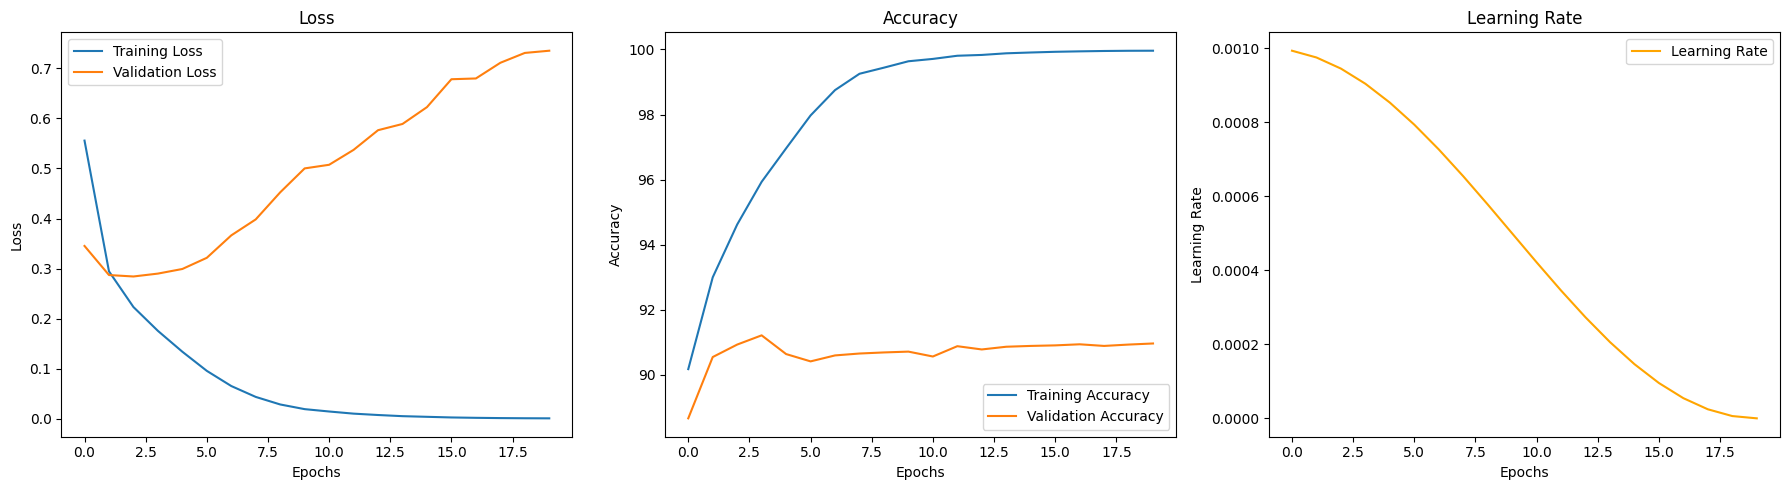

In [29]:
def plot_history(history):
    """
    Plots the training and validation loss, accuracy, and learning rate
    from a PyTorch history dictionary.

    Args:
        history (dict): Dictionary containing training metrics.
                        Expected keys: 'train_loss', 'val_loss', 'train_acc', 'val_acc', 'lrs'.
    """
    epochs = range(len(history['train_loss']))

    plt.figure(figsize=(18, 5))

    # Plot 1: Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], label='Training Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    # plt.grid(True)

    # Plot 2: Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['train_acc'], label='Training Accuracy')
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    # plt.grid(True)

    # Plot 3: Learning Rate
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['lrs'], label='Learning Rate', color='orange')
    plt.title('Learning Rate')
    plt.xlabel('Epochs')
    plt.ylabel('Learning Rate')
    plt.legend()
    # plt.grid(True)

    plt.tight_layout()
    plt.show()
    # plt.savefig()

plot_history(history)

---
## 4. Model Inference and Sentiment Prediction

---

In [30]:
# 1. Define the Human Labels
ag_news_labels = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

# 2. Re-use your Training Tokenizer
# This ensures "Don't" becomes ["don", "t"] consistently in both phases
tokenizer = lambda text: re.findall(r'\w+', text.lower())


# Adapted the below code from:
# https://github.com/bentrevett/pytorch-sentiment-analysis/blob/experimental/2%20-%20Upgraded%20Sentiment%20Analysis.ipynb
def predict_topic(model, sentence):
    model.eval()
    
    # Step A: Tokenize exactly like training
    tokens = tokenizer(sentence)
    
    # Step B: Numericalize using the <UNK> index (1)
    indexed = [vocab.get(t, 1) for t in tokens]
    
    # Step C: Prepare Tensors [Batch, Seq_Len]
    tensor = torch.LongTensor(indexed).unsqueeze(0).to(DEVICE)
    length = torch.LongTensor([len(indexed)]).to(DEVICE)
    
    with torch.no_grad():
        # Step D: Forward Pass
        logits = model(tensor, length)
        
        # Step E: Get the highest score
        # Using softmax to see the confidence %
        probs = torch.softmax(logits, dim=1)
        prediction_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][prediction_idx].item()
        
    return ag_news_labels[prediction_idx], confidence

# --- Test ----------------------------------------
headline = "The Olympic games were postponed due to global health concerns."
topic, score = predict_topic(model, headline)
print(f"Result: {topic} ({score:.2%})")

Result: Sports (100.00%)


In [31]:
# Create a list of test cases
ag_news_tests = [
    "The Federal Reserve is expected to keep interest rates steady as inflation cools.", # Business
    "The star striker scored a hat-trick in the final minutes of the world cup qualifier.", # Sports
    "Astronomers have discovered a new Earth-like planet orbiting a distant star system.", # Sci/Tech
    "Protests erupted in the capital city following the controversial election results.",    # World
    "New software update fixes critical security vulnerabilities in mobile operating systems." # Sci/Tech
]

print(f"{'Headline':<60} | {'Predicted Topic':<12} | {'Confidence'}")
print("-" * 85)

for text in ag_news_tests:
    topic, conf = predict_topic(model, text)
    print(f"{text[:58]:<60} | {topic:<12} | {conf:.2%}")

Headline                                                     | Predicted Topic | Confidence
-------------------------------------------------------------------------------------
The Federal Reserve is expected to keep interest rates ste   | Business     | 100.00%
The star striker scored a hat-trick in the final minutes o   | Sports       | 100.00%
Astronomers have discovered a new Earth-like planet orbiti   | Sci/Tech     | 100.00%
Protests erupted in the capital city following the controv   | World        | 99.99%
New software update fixes critical security vulnerabilitie   | Sci/Tech     | 100.00%


In [32]:
%watermark -iv

datasets   : 4.0.0
matplotlib : 3.10.0
numpy      : 2.0.2
pandas     : 2.3.3
re         : 2.2.1
sklearn    : 1.6.1
torch      : 2.9.0+cu126
torchinfo  : 1.8.0
torchvision: 0.24.0+cu126

